In [2]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs

In [3]:
# 1. Generate synthetic data
# We create 300 points centred around 4 specific "centers"
# X, y = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

import pandas as pd

# 'DATA\' tells Python to look inside the folder, then find the file
# https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/data
df = pd.read_csv('Data/Mall_Customers.csv')

# Show the first 5 rows to make sure it loaded correctly
df.head(5)


,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# 2. Initialise and fit the K-Means model
# n_clusters is the 'K' in K-Means
# kmeans = KMeans(n_clusters=4, init='k-means++', max_iter=300, n_init=10, random_state=0)
# pred_y = kmeans.fit_predict(X)

# Select only the columns we need for clustering
# Note: Use the exact column names from your df.columns output

X = df[['Annual_Income', 'Spending_Score']].values

In [6]:
# 3 Feature Scaling (Crucial)
# K-Means calculates the "Euclidean distance" between points. 
# If Income is in the thousands (15–137) and Spending is 1–100 
# The larger Income numbers will dominate the math. We need to put them on the same "playing field."

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# 4 The Elbow Method (Finding 'K')
# Since this is real data, we don't know how many groups of customers actually exist. 
# We run the model multiple times (1 to 10 clusters) and plot the "Inertia" (error). 
# We look for the "elbow" where the line stops dropping sharply.

C:\Users\j08490dd\AppData\Local\miniforge3\envs\mlcourse\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\j08490dd\AppData\Local\miniforge3\envs\mlcourse\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\j08490dd\AppData\Local\miniforge3\envs\mlcourse\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\j08490dd\AppData\Local\miniforg

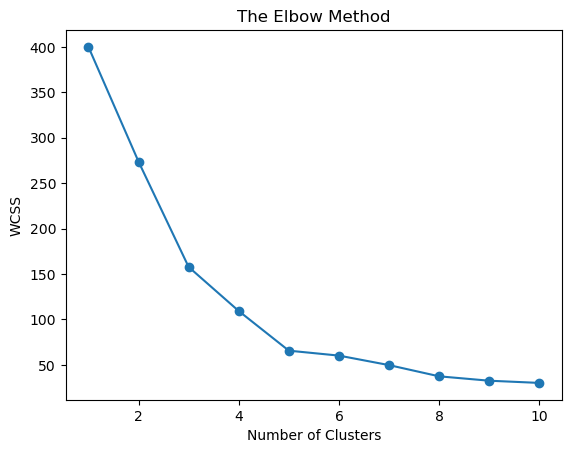

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = [] # Within-Cluster Sum of Squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [10]:
# 5 Run the Final Model
# Once you see the "elbow" (it's usually at 5 for this specific dataset)
# Run the model one last time with that number and save the results.

In [11]:
# Assuming the elbow was at 5
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# Add the cluster labels back to your original dataframe to see who is who!
df['Cluster'] = y_kmeans
df.head()

C:\Users\j08490dd\AppData\Local\miniforge3\envs\mlcourse\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


C:\Users\j08490dd\AppData\Local\miniforge3\envs\mlcourse\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


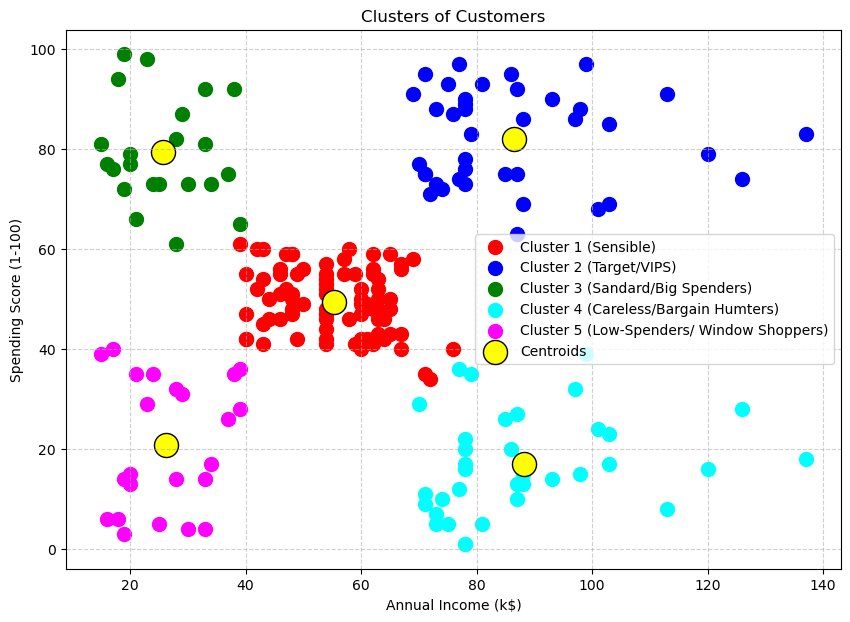

In [13]:
# 6. Run the final model
kmeans = KMeans(n_clusters=5, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# 7. Visualise the Clusters
plt.figure(figsize=(10, 7))

# Plotting each cluster using the original (unscaled) X values for readability
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s=100, c='red', label='Cluster 1 (Sensible)')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s=100, c='blue', label='Cluster 2 (Target/VIPS)')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s=100, c='green', label='Cluster 3 (Sandard/Big Spenders)')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s=100, c='cyan', label='Cluster 4 (Careless/Bargain Humters)')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s=100, c='magenta', label='Cluster 5 (Low-Spenders/ Window Shoppers)')

# Plotting the Centroids 
# Note: If you want to plot centroids on unscaled data, you'd need to inverse_transform them
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, c='yellow', label='Centroids', edgecolors='black')

plt.title('Clusters of Customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# How it Works (The "Why")
# A Pro Tip: The "Elbow Method"
# In the real world, you won't always know what K should be. 
# Data scientists use the Elbow Method 
# to find the optimal number of clusters by plotting the "Inertia" (sum of squared distances) 
# and looking for the "bend" in the graph.